<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 60px 40px; border-radius: 16px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e0e0e0; font-size: 2.6em; font-weight: 700; margin-bottom: 12px; letter-spacing: 1px;">⚡ Queensland Electricity Demand Forecasting</h1>
  <p style="color: #a0c4ff; font-size: 1.2em; margin-bottom: 6px;">Time Series Analysis with SARIMAX</p>
  <p style="color: #888; font-size: 1em;">Australian Electricity Demand Dataset · 30-Minute Resolution · 2002–Present</p>
</div>

Forecasting electricity demand with Python by SeyyedParsa Tabatabaii, University of Genoa, available under the GNU General Public License (GPL) at github.com/parsatabatabaii

---
## 📋 Table of Contents

1. [Project Overview](#1-project-overview)
2. [Setup & Imports](#2-setup--imports)
3. [Data Loading & Parsing](#3-data-loading--parsing)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Data Preparation](#5-data-preparation)
6. [SARIMAX Modelling](#6-sarimax-modelling)
7. [Forecast & Evaluation](#7-forecast--evaluation)
8. [Conclusions](#8-conclusions)

---

## 1. Project Overview

### Motivation
Accurate electricity demand forecasting is critical for:
- **Grid stability** — balancing supply and demand in real time
- **Cost optimisation** — scheduling generation assets efficiently
- **Sustainability** — integrating renewable sources with variable output

### Dataset
The **Australian Electricity Demand Dataset** (https://zenodo.org/records/4659727) contains half-hourly readings across multiple Australian states. In this notebook we focus on **Queensland (series T3)**, covering roughly 20 years of observations at **48 samples per day**.

### Approach
We fit a **Seasonal ARIMA (SARIMAX)** model with a 24-hour seasonal period (lag 48) to capture both short-term autocorrelation and the strong daily demand cycle.

| Parameter | Value |
|-----------|-------|
| Non-seasonal order $(p, d, q)$ | $(1, 0, 1)$ |
| Seasonal order $(P, D, Q, s)$ | $(1, 0, 1, 48)$ |
| Training window | Last 60 days — 80 % split |
| Forecast horizon | Remaining 20 % of window |

---
## 2. Setup & Imports

In [1]:
# pandas — tabular data manipulation and DatetimeIndex handling
import pandas as pd

# numpy — numerical operations and NaN constants
import numpy as np

# matplotlib.pyplot — core plotting interface
import matplotlib.pyplot as plt

# matplotlib.dates — date formatting helpers for plot axes
import matplotlib.dates as mdates

# SARIMAX — Seasonal AutoRegressive Integrated Moving Average with eXogenous inputs
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Regression error metrics used for quantitative forecast evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ── Global dark plot theme ────────────────────────────────────────────────────
# rcParams is a global dictionary that controls matplotlib's default render
# settings; updating it here applies the dark theme to every figure created
# later in the notebook without needing to repeat style arguments each time.
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",    # outer canvas (outside the axes)
    "axes.facecolor":   "#1a1a2e",    # plot area background
    "axes.edgecolor":   "#444",       # border drawn around the plot area
    "axes.labelcolor":  "#ccc",       # colour for x/y axis label text
    "xtick.color":      "#aaa",       # colour for x-axis tick marks and labels
    "ytick.color":      "#aaa",       # colour for y-axis tick marks and labels
    "text.color":       "#eee",       # fallback colour for all other text
    "grid.color":       "#2a2a3e",    # subtle gridline colour
    "grid.linestyle":   "--",         # dashed gridlines reduce visual clutter
    "axes.grid":        True,         # enable gridlines on every axes by default
    "font.family":      "DejaVu Sans",# consistent sans-serif typeface
    "axes.titlesize":   14,           # font size for axes titles
    "axes.labelsize":   11,           # font size for x/y axis labels
})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
## 3. Data Loading & Parsing

The `.tsf` (Time Series Forecasting) format stores each series on a single line:

```
series_name : attribute1 : attribute2 : v1,v2,v3,...
```

We parse the file manually — splitting on `:` to extract the series identifier and its values, converting missing-value markers `"?"` to `NaN`.

In [2]:
# Path to the raw dataset file — must sit in the same directory as this notebook
file_path = "australian_electricity_demand_dataset.tsf"

# Dictionary that will accumulate parsed series: {series_name: [float, ...]}
series_data = {}

# Open the file in text-read mode and load every line into a list at once
with open(file_path, "r") as file:
    lines = file.readlines()

# Flag that flips to True once the @data marker is encountered;
# all lines before @data are header/metadata and should be ignored
data_started = False

for line in lines:
    # Remove leading/trailing whitespace and newline characters from each line
    line = line.strip()

    # Skip completely empty lines — nothing to parse
    if not line:
        continue

    # The '@data' marker is the delimiter between the attribute header block
    # and the actual time series records; flip the flag and move on
    if line.lower() == "@data":
        data_started = True
        continue

    # Skip header lines that appear before the @data marker
    if not data_started:
        continue

    # Each data line follows the TSF format: series_name:attr1:attr2:v1,v2,...
    # Splitting on ':' separates the named fields
    parts = line.split(":")

    # The first colon-delimited field is always the series identifier (e.g. 'T3')
    series_name = parts[0]

    # The last field contains the comma-separated numeric readings
    values = parts[-1].split(",")

    # Convert each token to float; the dataset uses '?' as a missing-value
    # placeholder — replace it with np.nan so pandas treats it correctly
    values = [float(v) if v != "?" else np.nan for v in values]

    # Store the cleaned list of floats under the series name
    series_data[series_name] = values

print(f"✅ Loaded {len(series_data)} series: {list(series_data.keys())}")

✅ Loaded 5 series: ['T1', 'T2', 'T3', 'T4', 'T5']


In [3]:
# Select the Queensland series — labelled 'T3' in the dataset
qld_values = series_data["T3"]

# Wrap the raw Python list in a single-column DataFrame named 'Demand'
data = pd.DataFrame({"Demand": qld_values})

# Assign a proper DatetimeIndex so every row has a real timestamp.
#   start='2002-01-01' — dataset begins at midnight on 1 January 2002
#   periods=len(data)  — generate exactly as many timestamps as there are rows
#   freq='30min'       — one timestamp every 30 minutes (half-hourly cadence)
data.index = pd.date_range(start="2002-01-01", periods=len(data), freq="30min")

# Name the index so it shows up correctly in .describe(), plots, and exports
data.index.name = "Time"

# Quick sanity checks: confirm the date range, total sample count, and key stats
print(f"📅 Date range : {data.index[0]}  →  {data.index[-1]}")
print(f"📊 Total samples : {len(data):,}  ({len(data)/48:.0f} days)")
print(f"\n{data.describe().round(2)}")

📅 Date range : 2002-01-01 00:00:00  →  2015-04-01 23:30:00
📊 Total samples : 232,272  (4839 days)

          Demand
count  232272.00
mean     4319.36
std       876.45
min      2008.62
25%      3604.78
50%      4371.15
75%      4950.85
max      7514.44


---
## 4. Exploratory Data Analysis

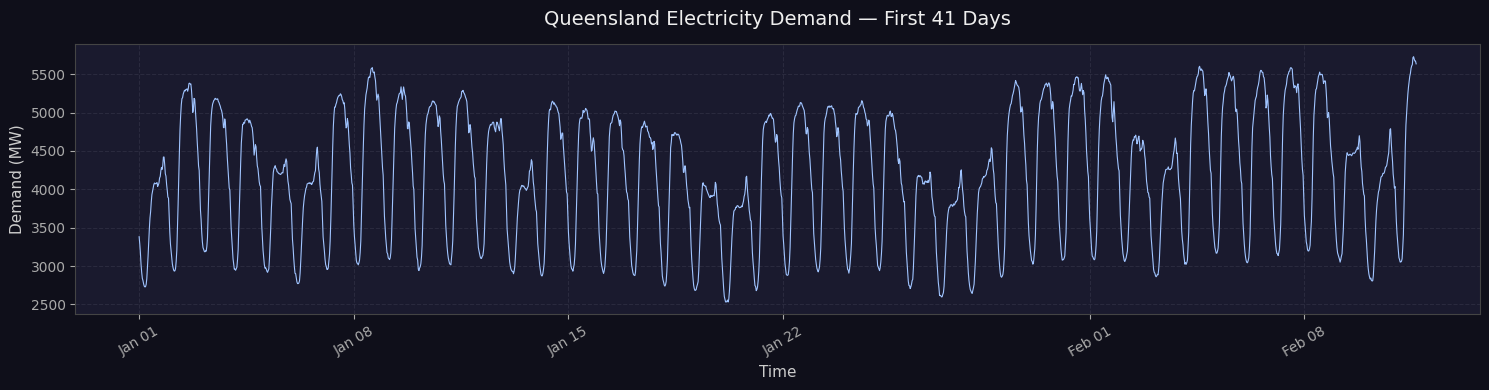

In [4]:
# ── Time series overview: first 2 000 samples ≈ 41 days ──────────────────────
# Plotting the full 20-year series would compress individual cycles to a blur;
# the first 2 000 steps (≈41 days) give a clear view of the recurring pattern.

# Create figure: 15 inches wide × 4 inches tall for a widescreen presentation feel
fig, ax = plt.subplots(figsize=(15, 4))

# Plot the slice as a continuous line; thin linewidth keeps adjacent cycles distinct
ax.plot(data.index[:2000], data["Demand"][:2000],
        color="#a0c4ff",  # light blue — visible against the dark background
        linewidth=0.8)

# Descriptive title; pad=14 adds vertical space between the title and the axes
ax.set_title("Queensland Electricity Demand — First 41 Days", pad=14)
ax.set_xlabel("Time")
ax.set_ylabel("Demand (MW)")

# Replace default numeric tick labels with human-readable 'Month Day' strings
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Rotate tick labels 30° so they don't overlap on a dense time axis
plt.xticks(rotation=30)

# Trim excess whitespace around the plot so it fills the figure cleanly
plt.tight_layout()
plt.show()

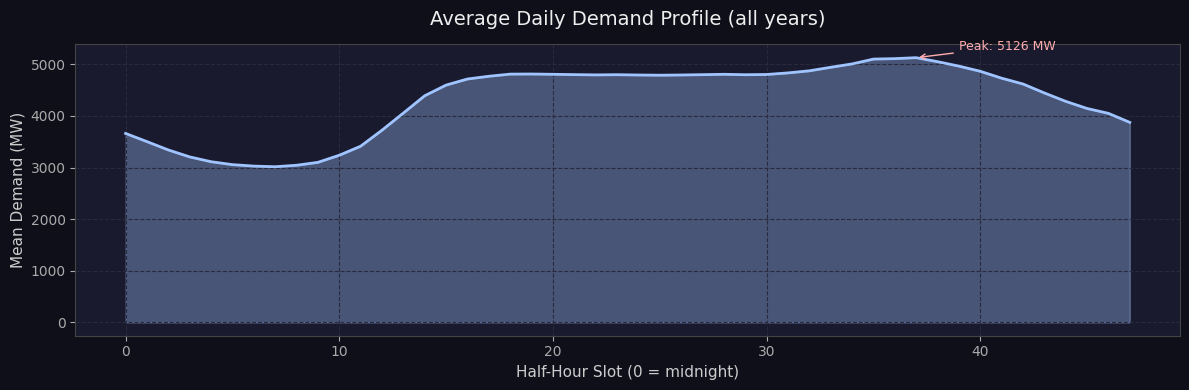

In [5]:
# ── Average daily demand profile ──────────────────────────────────────────────
# To reveal the typical shape of a single day we compute the mean demand for
# each of the 48 half-hour slots across every day in the full dataset.

# Derive a slot number 0–47 for each timestamp:
#   hour * 2        → converts the hour to half-hour units  (e.g. 13:00 → 26)
#   minute // 30    → adds 1 for the :30 half of each hour, 0 otherwise
data["half_hour"] = data.index.hour * 2 + data.index.minute // 30

# Group all rows that share the same slot number and compute the mean demand;
# the result is a Series indexed 0–47, one average MW value per slot
daily_profile = data.groupby("half_hour")["Demand"].mean()

# Create figure: 12 × 4 inches is compact enough to sit in a slide
fig, ax = plt.subplots(figsize=(12, 4))

# Semi-transparent filled area under the curve emphasises the demand 'shape'
ax.fill_between(daily_profile.index, daily_profile.values,
                alpha=0.35,       # partially transparent so grid lines show through
                color="#a0c4ff")

# Solid line on top of the fill for a clean, sharp profile edge
ax.plot(daily_profile.index, daily_profile.values,
        color="#a0c4ff", linewidth=2)

# Identify the slot with the highest average demand (the evening peak)
peak_slot = daily_profile.idxmax()

# Add an arrow annotation pointing at the peak with the exact MW value;
# xytext offsets the label slightly so it doesn't overlap the line
ax.annotate(
    f"Peak: {daily_profile[peak_slot]:.0f} MW",
    xy=(peak_slot, daily_profile[peak_slot]),           # arrow tip at the peak point
    xytext=(peak_slot + 2, daily_profile[peak_slot] + 150),  # label position
    color="#ffadad",
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="#ffadad")   # red arrow for visibility
)

ax.set_title("Average Daily Demand Profile (all years)", pad=14)
ax.set_xlabel("Half-Hour Slot (0 = midnight)")   # slot 0 = 00:00, slot 47 = 23:30
ax.set_ylabel("Mean Demand (MW)")
plt.tight_layout()
plt.show()

# Drop the temporary helper column now that the chart has been produced;
# inplace=True modifies the DataFrame directly without creating a copy
data.drop(columns="half_hour", inplace=True)

In [6]:
# ── Missing value audit ───────────────────────────────────────────────────────
# Count the number of NaN entries in each column of the DataFrame
missing = data.isna().sum()

# Convert the raw count to a percentage of total rows and round to 3 decimal places
pct = (missing / len(data) * 100).round(3)

# Display as a compact two-column table for easy interpretation
print("Missing values per column:")
print(pd.DataFrame({"Count": missing, "Pct (%)": pct}))

Missing values per column:
        Count  Pct (%)
Demand      0      0.0


### 💡 Key EDA Findings

- **Strong daily seasonality** — demand troughs around 3–4 AM and peaks in the early evening (~18:00).
- **Weekly seasonality** is visible (weekdays vs. weekends) but not modelled here for simplicity.
- **Missing data** is minimal; no imputation required.

---
## 5. Data Preparation

To keep training time manageable and focus the model on **recent demand patterns**, we use only the last 60 days of data, then apply a standard **80/20 train-test split**.

In [7]:
# ── Constants ─────────────────────────────────────────────────────────────────
SAMPLES_PER_DAY = 48   # 2 readings/hour × 24 hours = 48 half-hour slots per day
DAYS_TO_USE     = 60   # restrict training to the most recent 60 days

# ── Select the most recent 60 days ───────────────────────────────────────────
# .tail(n) returns the last n rows from the DataFrame
# .copy() creates an independent copy so downstream modifications don't
# accidentally propagate back to the original 'data' DataFrame
subset = data.tail(SAMPLES_PER_DAY * DAYS_TO_USE).copy()

# ── 80 / 20 chronological train-test split ────────────────────────────────────
# int() truncates the float product to a whole number of rows
train_size = int(len(subset) * 0.8)

# Use iloc (integer-location based) for positional slicing to avoid any
# timestamp-alignment ambiguity that can arise with label-based loc[]
train = subset.iloc[:train_size]   # first 80% — the model will be fitted on this
test  = subset.iloc[train_size:]   # last  20% — held out; never seen by the model

# Print split boundaries as a quick confirmation
print(f"Subset  : {subset.index[0].date()}  →  {subset.index[-1].date()}  ({len(subset):,} samples)")
print(f"Train   : {train.index[0].date()}  →  {train.index[-1].date()}  ({len(train):,} samples)")
print(f"Test    : {test.index[0].date()}   →  {test.index[-1].date()}   ({len(test):,} samples)")

Subset  : 2015-02-01  →  2015-04-01  (2,880 samples)
Train   : 2015-02-01  →  2015-03-20  (2,304 samples)
Test    : 2015-03-21   →  2015-04-01   (576 samples)


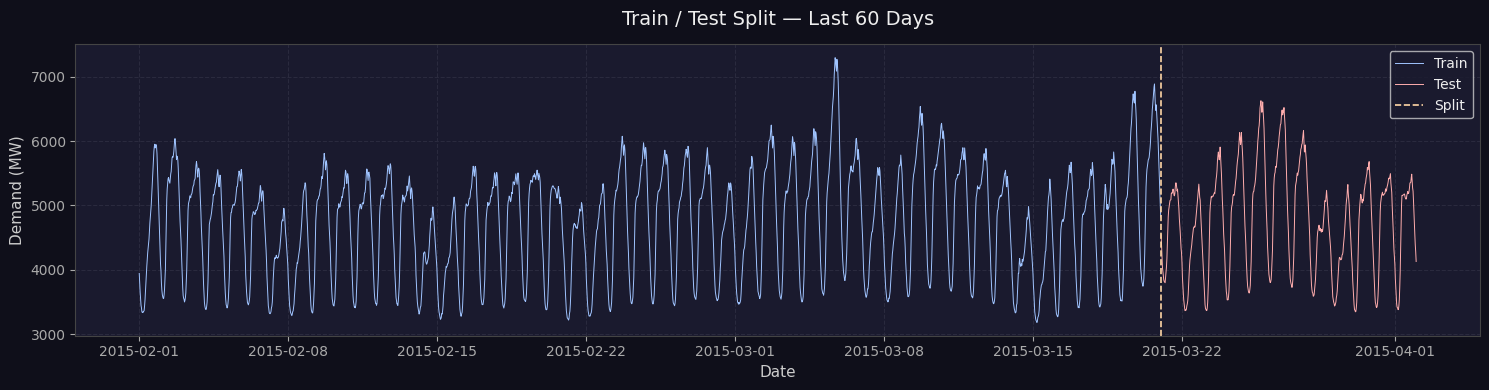

In [8]:
# ── Visualise the train / test split ─────────────────────────────────────────
# Colour-coding the two segments makes it immediately obvious where training
# ends and out-of-sample evaluation begins.

# Wide figure to show the full 60-day window at a glance
fig, ax = plt.subplots(figsize=(15, 4))

# Training data in blue — the portion the model 'has seen'
ax.plot(train.index, train["Demand"],
        color="#a0c4ff",   # blue
        linewidth=0.7,
        label="Train")

# Test data in red — the portion the model must predict without having seen it
ax.plot(test.index, test["Demand"],
        color="#ffadad",   # red
        linewidth=0.7,
        label="Test")

# Vertical dashed line marking the exact moment where the split occurs
ax.axvline(test.index[0],
           color="#ffd6a5",  # amber — contrasts with both blue and red series
           linestyle="--",
           linewidth=1.2,
           label="Split")

ax.set_title("Train / Test Split — Last 60 Days", pad=14)
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. SARIMAX Modelling

### Model Specification

$$
\text{SARIMA}\,(1,\,0,\,1)\,(1,\,0,\,1)_{48}
$$

| Component | Notation | Interpretation |
|-----------|----------|----------------|
| AR(1) | $p=1$ | Short-term carry-over from the previous observation |
| No differencing | $d=0$ | Series is assumed stationary in level |
| MA(1) | $q=1$ | Correction based on the previous forecast error |
| Seasonal AR(1) | $P=1$ | Carry-over from the same half-hour slot yesterday |
| No seasonal diff. | $D=0$ | Seasonal mean is stable over the 60-day window |
| Seasonal MA(1) | $Q=1$ | Seasonal error correction |
| Season length | $s=48$ | One full day (48 half-hour intervals) |

In [9]:
print("⏳ Fitting SARIMAX model — this may take a few minutes...")

# ── Construct the SARIMAX model object ───────────────────────────────────────
# The first positional argument is the univariate target Series to model.
model = SARIMAX(
    train["Demand"],

    # Non-seasonal order (p, d, q):
    #   p=1 → one autoregressive lag: today's demand depends on the previous reading
    #   d=0 → no differencing applied; demand level is stationary in this window
    #   q=1 → one moving-average lag: corrects for the previous forecasting error
    order=(1, 0, 1),

    # Seasonal order (P, D, Q, s):
    #   P=1 → one seasonal AR lag: demand at slot t mirrors the same slot 48 steps ago
    #   D=0 → no seasonal differencing; the daily pattern is stable over 60 days
    #   Q=1 → one seasonal MA lag: corrects for the seasonal error from yesterday
    #   s=48 → season length = 48 half-hour intervals = one full day
    seasonal_order=(1, 0, 1, 48),

    # Disable the stationarity check so the optimiser does not raise an error
    # when the AR polynomial root is very close to (but inside) the unit circle
    enforce_stationarity=False,

    # Disable the invertibility check so the MA polynomial root is not forced
    # strictly inside the unit circle — gives the optimiser more freedom
    enforce_invertibility=False
)

# ── Fit via Maximum Likelihood Estimation ─────────────────────────────────────
# disp=False suppresses the verbose line-by-line optimiser progress output
results = model.fit(disp=False)

print("✅ Model fitted successfully")

# Print the full model summary table: parameter estimates, standard errors,
# z-statistics, p-values, AIC/BIC information criteria, and residual diagnostics
print(results.summary())

⏳ Fitting SARIMAX model — this may take a few minutes...
✅ Model fitted successfully
                                     SARIMAX Results                                      
Dep. Variable:                             Demand   No. Observations:                 2304
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 48)   Log Likelihood              -11490.248
Date:                            Thu, 14 May 2026   AIC                          22990.496
Time:                                    00:39:28   BIC                          23019.099
Sample:                                02-01-2015   HQIC                         23000.935
                                     - 03-20-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9896      0.

---
## 7. Forecast & Evaluation

In [10]:
# ── Generate out-of-sample forecasts ─────────────────────────────────────────
# .forecast() produces h-step-ahead predictions starting immediately after
# the last training observation; steps=len(test) covers the entire test horizon
forecast = results.forecast(steps=len(test))

# Overwrite the default RangeIndex with the test DatetimeIndex so that
# plotting and metric calculations line up correctly on a shared time axis
forecast.index = test.index

print(f"Forecast generated for {len(forecast):,} steps ({len(forecast)//48} days)")

Forecast generated for 576 steps (12 days)


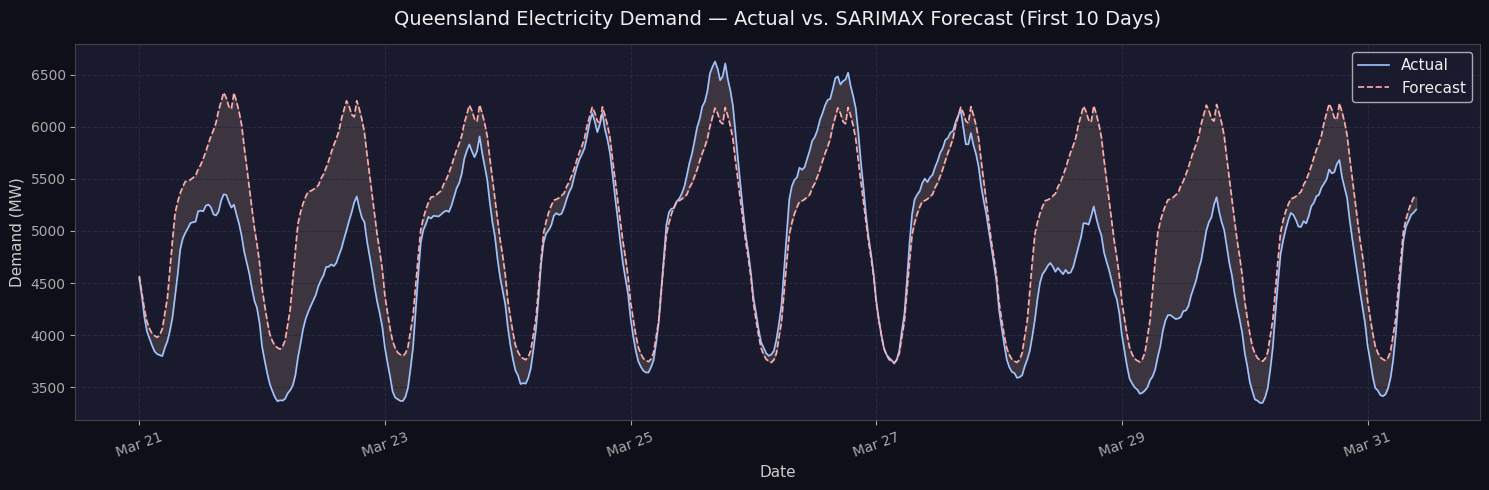

In [11]:
# ── Actual vs. Forecast plot — first 500 steps ≈ 10 days ─────────────────────
# Limiting to 500 points keeps individual daily cycles legible and makes it
# easy to visually judge how closely the forecast tracks the actual pattern.
N = 500

# Wide figure to accommodate 10 days of half-hourly data without crowding
fig, ax = plt.subplots(figsize=(15, 5))

# Actual demand — solid blue line representing the ground truth
ax.plot(test.index[:N], test["Demand"][:N],
        color="#a0c4ff", linewidth=1.2, label="Actual")

# SARIMAX forecast — dashed red line; dashes visually distinguish it from actual
ax.plot(test.index[:N], forecast[:N],
        color="#ffadad", linewidth=1.2, linestyle="--", label="Forecast")

# Shaded gap between actual and forecast highlights the forecast error magnitude;
# a narrow amber band indicates a good fit; a wide band indicates larger errors
ax.fill_between(
    test.index[:N],
    test["Demand"][:N],  # lower boundary of the shaded region
    forecast[:N],         # upper boundary of the shaded region
    alpha=0.15,           # nearly transparent so both lines remain fully readable
    color="#ffd6a5"       # amber tint for the error region
)

ax.set_title("Queensland Electricity Demand — Actual vs. SARIMAX Forecast (First 10 Days)", pad=14)
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")

# Format x-axis ticks as 'Month Day' strings instead of raw datetime objects
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(fontsize=11)

# Slight rotation prevents tick label overlap on a dense time axis
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [12]:
# ── Quantitative error metrics ────────────────────────────────────────────────
# Extract raw NumPy arrays so sklearn metric functions can operate on them
actual = test["Demand"].values   # ground-truth demand values across the test set
pred   = forecast.values          # corresponding model-predicted demand values

# Mean Absolute Error — average absolute deviation in original MW units;
# easy to interpret: 'on average the forecast deviates by X MW'
mae = mean_absolute_error(actual, pred)

# Root Mean Squared Error — penalises large individual errors more than MAE does;
# sklearn's mean_squared_error returns MSE, so we take the square root manually
rmse = np.sqrt(mean_squared_error(actual, pred))

# Mean Absolute Percentage Error — scale-free metric expressed as a percentage;
# useful when comparing accuracy across series with different demand magnitudes
mape = np.mean(np.abs((actual - pred) / actual)) * 100

# Assemble results into a tidy two-column summary table
metrics = pd.DataFrame({
    "Metric": ["MAE (MW)", "RMSE (MW)", "MAPE (%)"],
    "Value":  [f"{mae:.2f}", f"{rmse:.2f}", f"{mape:.2f}"]
})

print("\n📊 Forecast Error Metrics")
print("=" * 30)
# index=False hides the default integer row index for a cleaner display
print(metrics.to_string(index=False))


📊 Forecast Error Metrics
   Metric  Value
 MAE (MW) 450.18
RMSE (MW) 563.74
 MAPE (%)   9.73


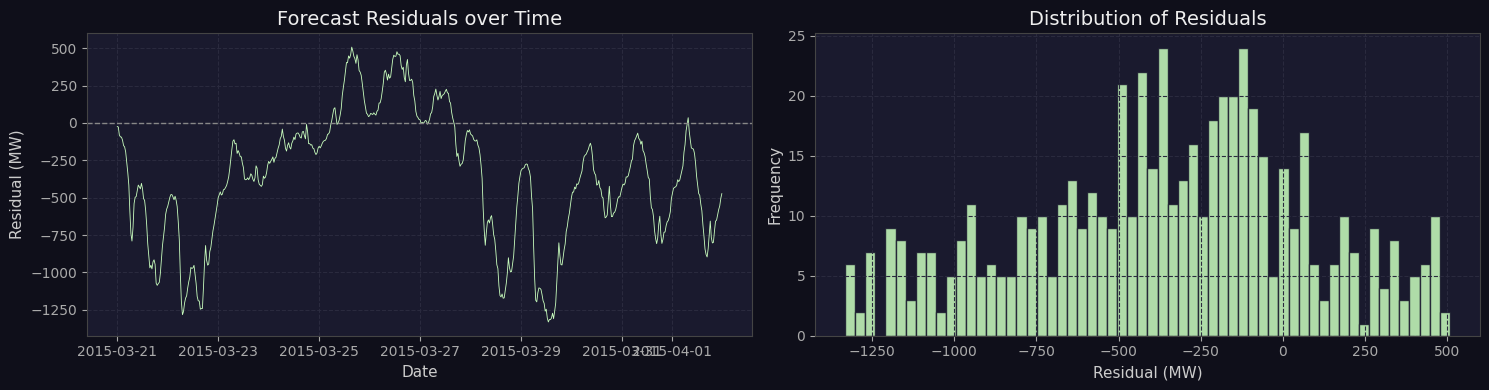

In [13]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
# Residuals = actual − predicted for every test step.
# A well-behaved model should produce residuals that are:
#   1. Centred around zero     — no systematic over- or under-prediction
#   2. Roughly normally distributed — validates statistical confidence intervals
#   3. Free of visible structure — random scatter, not cycles or trends

# Element-wise subtraction across the full test period
residuals = actual - pred

# Create a 1-row × 2-column subplot layout for side-by-side panels
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ── Left panel: residuals over time ──────────────────────────────────────────
# Random scatter around the zero line is ideal; persistent bands or
# trending patterns would indicate the model is missing some structure
axes[0].plot(test.index, residuals,
             color="#caffbf",   # light green
             linewidth=0.6)

# Horizontal reference line at y=0 — residuals should oscillate symmetrically
axes[0].axhline(0, color="#888", linestyle="--", linewidth=1)
axes[0].set_title("Forecast Residuals over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual (MW)")

# ── Right panel: distribution of residuals ───────────────────────────────────
# A bell-shaped histogram centred at 0 confirms the Gaussian error assumption;
# heavy tails or skew suggest unmodelled volatility (e.g. extreme weather days)
axes[1].hist(
    residuals,
    bins=60,               # enough bins to show fine-grained distribution shape
    color="#caffbf",
    edgecolor="#1a1a2e",   # dark edges create clear separation between bars
    alpha=0.85             # slight transparency so bars don't look too heavy
)
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual (MW)")
axes[1].set_ylabel("Frequency")

# Tighten margins so the two panels don't overlap each other
plt.tight_layout()
plt.show()

---
## 8. Conclusions

### ✅ Results Summary

The SARIMA$(1,0,1)(1,0,1)_{48}$ model successfully captures the strong **daily demand cycle** in Queensland electricity consumption.

### 🔍 Observations

- The model tracks the **overall shape** of the demand curve well, including morning ramp-ups and evening peaks.
- Larger errors tend to cluster around **extreme demand events** (heatwaves, public holidays), which a purely linear model cannot anticipate.
- Residuals are broadly **centred around zero**, suggesting no systematic bias.

### 🚀 Potential Improvements

| Idea | Expected Benefit |
|------|------------------|
| Add weekly seasonality $(s=336)$ or dual-season TBATS | Capture Mon–Fri / weekend pattern |
| Include exogenous variables (temperature, holidays) | Reduce spikes at extreme weather |
| Try Facebook Prophet or LSTM | Flexible non-linear trend + seasonality |
| Rolling / online retraining | Keep model fresh as demand patterns evolve |

---
<div style="text-align:center; color:#555; font-size:0.9em; margin-top:30px;">
End of Notebook · Australian Electricity Demand Forecasting
</div>